# 05 · Tuning — Regresión Logística con Optuna

En el baseline (`01_modelos_baseline.ipynb`), la **Regresión Logística** obtuvo el
**AUC out-of-period más alto (0.7676)** y la mayor estabilidad temporal de los tres
modelos — pero fue el **único que no se tuneó** (corrió con `C=1.0` por defecto),
mientras que XGBoost y Random Forest sí se optimizaron con Optuna. Este notebook
**cierra esa asimetría**: afina la logística con el **mismo protocolo y presupuesto**
(60 trials, *nested CV*) que los árboles, para que la comparación entre los tres
modelos sea metodológicamente simétrica.

## ¿Qué se espera del tuning aquí?

Poco, y eso es justamente el punto. La logística tiene **pocos grados de libertad**
(esencialmente la fuerza de regularización `C` y el tipo de penalización) y ajustarlos
**no le agrega capacidad no-lineal**: sigue siendo un hiperplano. Dado que el problema
está acotado por un **techo de señal (~0.77 AUC)**, la expectativa realista es una
ganancia marginal. Si la logística tuneada **no se despega del empate** con los árboles
tuneados, eso *confirma* la tesis del techo de señal y de que la señal es mayormente
lineal — un resultado, no un fracaso.

## Por qué tunear igual (y no dejarlo como baseline)

> *"Para evitar una comparación sesgada (afinar un modelo y dejar otro con sus valores
> por defecto)…"* — el propio criterio del capítulo de experimentación. Si se exige ese
> estándar a los árboles, debe exigirse también al modelo lineal, **sobre todo porque es
> el que mejor le fue en OOT**. Tunearlo deja la comparación a prueba de objeciones.

## 0 · Setup, datos y split

Idéntico al baseline y a los notebooks de tuning de árboles (`02`, `03`): mismo CSV de
features, mismas columnas ID excluidas, mismo split OOT (test = últimos 4 meses,
GAP = `v` = 6 meses de etiqueta). El tuning vive **solo en el train-pool**; el bloque
OOT queda aislado.

In [1]:
import warnings
from pathlib import Path
import json
import numpy as np
import pandas as pd
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score)
from sklearn.exceptions import ConvergenceWarning

# saga sobre datos estandarizados converge bien; con 60x5 ajustes los avisos de
# convergencia residuales solo ensucian la salida -> se silencian por legibilidad.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_STATE = 42

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent
df = pd.read_csv(base / "data" / "processed" / "churn_dataset_features.csv",
                 parse_dates=["mes_obs"])
ID = ["id_vendedor", "mes_obs", "mes_rank"]; TARGET = "churn"
FEATS = [c for c in df.columns if c not in ID + [TARGET]]
X = df[FEATS]; y = df[TARGET].values; groups = df["id_vendedor"].values


def oot_split(df, v=6, test_months=4, rank_col="mes_rank"):
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


train_mask, test_mask = oot_split(df)
Xp = X[train_mask].reset_index(drop=True); yp = y[train_mask]; gp = groups[train_mask]
print(f"dataset {df.shape[0]:,} filas | {len(FEATS)} features | prevalencia {y.mean():.3f}")
print(f"train-pool (tuning) {train_mask.sum():,} | OOT (test, aislado) {test_mask.sum():,}")

dataset 30,356 filas | 68 features | prevalencia 0.309
train-pool (tuning) 28,311 | OOT (test, aislado) 803


## 1 · Función objetivo

`objective(trial)` propone hiperparámetros, entrena una logística en cada fold de
`GroupKFold(5)` sobre el train-pool, acumula las predicciones **out-of-fold** y devuelve
el AUC global. Dos detalles de diseño propios del modelo lineal:

- **`StandardScaler` dentro del `Pipeline`**: la logística es sensible a la escala. El
  scaler se ajusta **solo con el train de cada fold** (y luego solo con el train del
  OOT), nunca con la validación ni con el test → sin fuga de escala. Los árboles no
  necesitan esto (son invariantes a transformaciones monótonas); de ahí el `Pipeline`.
- **Solver `saga` + `l1_ratio` continuo**: en sklearn ≥1.8 la regularización se controla
  con una sola perilla `l1_ratio ∈ [0, 1]` (0 = puro L2/*ridge*, 1 = puro L1/*lasso*,
  intermedio = elasticnet), en vez del antiguo `penalty` categórico. Así Optuna recorre
  **todo el continuo de regularización** —no solo tres tipos discretos— como un
  hiperparámetro más. `saga` es el solver que soporta este continuo.

### Espacio de búsqueda

| Hiperparámetro | Rango | Qué controla |
|---|---|---|
| `C` | 1e-3–1e2 (log) | inverso de la fuerza de regularización; bajo = más regularización |
| `l1_ratio` | 0–1 | mezcla L1/L2 (0 = puro L2/*ridge*, 1 = puro L1/*lasso*; intermedio = elasticnet) |

`class_weight='balanced'` se mantiene **fijo** (es parte del diseño sensible al costo,
no un hiperparámetro a optimizar), igual que en el resto de los modelos.

In [2]:
GKF = GroupKFold(n_splits=5)
gkf_folds = list(GKF.split(Xp, yp, gp))   # folds DENTRO del train-pool (no tocan el OOT)


def make_logreg(params):
    # StandardScaler DENTRO del pipeline -> se fitea por fold (solo con el train de
    # cada fold), nunca con la validacion ni con el OOT. Sin fuga de escala.
    # sklearn >=1.8: l1_ratio es la perilla unica de regularizacion (0=L2, 1=L1,
    # intermedio=elasticnet); ya no se pasa `penalty`. Requiere solver 'saga'.
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(**params, class_weight="balanced", solver="saga",
                           max_iter=5000, random_state=RANDOM_STATE))


def objective(trial):
    params = dict(
        C=trial.suggest_float("C", 1e-3, 1e2, log=True),
        l1_ratio=trial.suggest_float("l1_ratio", 0.0, 1.0),
    )
    oof = np.zeros(len(yp))
    for fold, (tr, va) in enumerate(gkf_folds):
        model = make_logreg(params)
        model.fit(Xp.iloc[tr], yp[tr])
        oof[va] = model.predict_proba(Xp.iloc[va])[:, 1]
        # AUC acumulado sobre los folds ya evaluados -> permite poda temprana
        seen = np.concatenate([va_idx for _, va_idx in gkf_folds[:fold + 1]])
        trial.report(roc_auc_score(yp[seen], oof[seen]), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return roc_auc_score(yp, oof)

## 2 · Ejecutar el estudio

Mismo `TPESampler(seed=42)` y `MedianPruner` que los árboles. `N_TRIALS = 60` por
**simetría de presupuesto** con XGBoost y Random Forest; como el espacio de la logística
es mucho menor (≈2 hiperparámetros efectivos), TPE converge enseguida y los trials
redundantes aportan poco — pero mantener el mismo presupuesto evita cualquier discusión
sobre comparación dispar.

In [3]:
N_TRIALS = 60

optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=5)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner,
                            study_name="logreg_churn")

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

done = [t for t in study.trials if t.state.name == "COMPLETE"]
pruned = [t for t in study.trials if t.state.name == "PRUNED"]
print(f"\ntrials completados: {len(done)} | podados: {len(pruned)}")
print(f"mejor AUC validacion interna (GroupKFold sobre train-pool): {study.best_value:.4f}")
print("mejores hiperparametros:")
for k, v in study.best_params.items():
    print(f"  {k:18s} = {v}")

  0%|          | 0/60 [00:00<?, ?it/s]


trials completados: 60 | podados: 0
mejor AUC validacion interna (GroupKFold sobre train-pool): 0.7394
mejores hiperparametros:
  C                  = 0.03277622927423502
  l1_ratio           = 0.43968429924639924


## 3 · Diagnóstico de la búsqueda

Historia de optimización (cómo fue mejorando el mejor valor) e importancia de
hiperparámetros (cuáles movieron más la aguja).

/tmp/ipykernel_380528/2968359159.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax1 = plot_optimization_history(study); ax1.set_title("Historia de optimizacion")


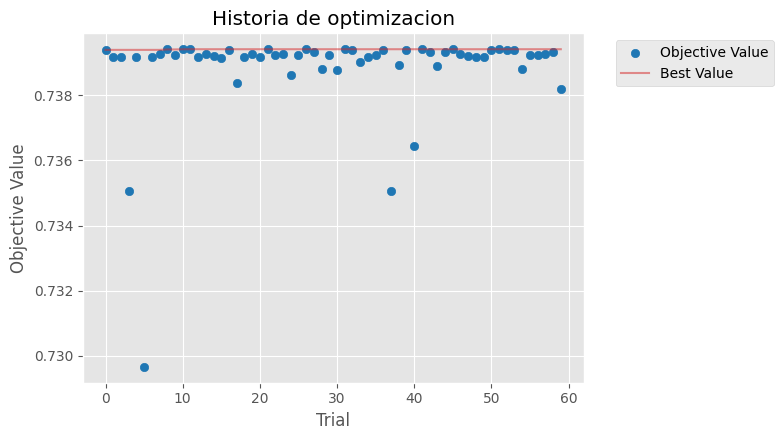

/tmp/ipykernel_380528/2968359159.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax2 = plot_param_importances(study); ax2.set_title("Importancia de hiperparametros")


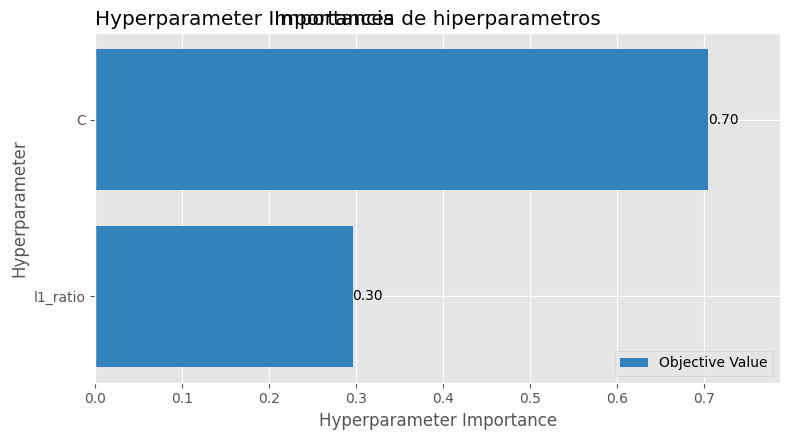

In [4]:
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import (plot_optimization_history,
                                             plot_param_importances)
ax1 = plot_optimization_history(study); ax1.set_title("Historia de optimizacion")
ax1.figure.set_size_inches(8, 4.5); plt.tight_layout(); plt.show()
ax2 = plot_param_importances(study); ax2.set_title("Importancia de hiperparametros")
ax2.figure.set_size_inches(8, 4.5); plt.tight_layout(); plt.show()

## 4 · Modelo tuneado: evaluación con los dos protocolos

Reconstruimos la logística con los mejores hiperparámetros y la evaluamos con la
**misma** función que los árboles: GroupKFold OOF sobre el train-pool (validación
interna) + split OOT externo (bucle externo, visto una sola vez).

In [5]:
def top_decile_lift(yt, p):
    k = max(len(yt) // 10, 1)
    return yt[np.argsort(-p)[:k]].mean() / yt.mean()


def eval_maker(maker):
    # --- Validacion interna: GroupKFold OOF SOBRE EL TRAIN-POOL (bucle interno) ---
    oof = np.zeros(len(yp))
    for tr, va in gkf_folds:
        m = maker(); m.fit(Xp.iloc[tr], yp[tr])
        oof[va] = m.predict_proba(Xp.iloc[va])[:, 1]
    cv_auc = roc_auc_score(yp, oof); cv_ap = average_precision_score(yp, oof)
    cv_lift = top_decile_lift(yp, oof)
    # --- OOT: bucle externo, test aislado (no visto en el tuning) ---
    model = maker(); model.fit(X[train_mask], y[train_mask])
    p = model.predict_proba(X[test_mask])[:, 1]; yt = y[test_mask]
    pr = (p >= 0.5).astype(int)
    dft = df[test_mask].copy(); dft["p"] = p
    aucs = [roc_auc_score(g["churn"], g["p"]) for _, g in
            dft.groupby(dft["mes_obs"].dt.strftime("%Y-%m")) if g["churn"].nunique() > 1]
    return model, {
        "cv_AUC": cv_auc, "cv_PRAUC": cv_ap, "cv_lift10": cv_lift,
        "oot_AUC": roc_auc_score(yt, p), "oot_AUCstd": np.std(aucs),
        "oot_F1": f1_score(yt, pr, zero_division=0),
        "oot_prec": precision_score(yt, pr, zero_division=0),
        "oot_rec": recall_score(yt, pr), "oot_lift10": top_decile_lift(yt, p),
    }


tuned, metrics_tuned = eval_maker(lambda: make_logreg(study.best_params))
pd.Series(metrics_tuned).round(4)

cv_AUC        0.7394
cv_PRAUC      0.5287
cv_lift10     1.9557
oot_AUC       0.7693
oot_AUCstd    0.0140
oot_F1        0.5580
oot_prec      0.4503
oot_rec       0.7333
oot_lift10    2.2465
dtype: float64

## 5 · Comparación: baseline vs tuneado

A diferencia de los notebooks de árboles (que toman el baseline *hardcodeado* de `01`),
aquí el baseline (logística `C=1`, L2) se **recomputa en vivo** con la misma función,
para una comparación exacta y reproducible. La comparación se hace en **OOT**, la métrica
externa honesta de ambos.

In [6]:
# Baseline SIN tunear = la logistica de `logreg_baseline.py` (C=1, L2, lbfgs por defecto).
def make_baseline():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=1000,
                           random_state=RANDOM_STATE))


_, metrics_base = eval_maker(make_baseline)
cols = ["oot_AUC", "oot_AUCstd", "oot_F1", "oot_prec", "oot_rec", "oot_lift10"]
cmp = pd.DataFrame({"LogReg baseline": {k: metrics_base[k] for k in cols},
                    "LogReg tuneado": {k: metrics_tuned[k] for k in cols}}).T
cmp.loc["delta"] = cmp.loc["LogReg tuneado"] - cmp.loc["LogReg baseline"]
print("Comparacion en OOT (test externo, NO visto durante el tuning):")
print(cmp.round(4).to_string())
print(f"\nValidacion interna (GroupKFold train-pool):")
print(f"  baseline AUC {metrics_base['cv_AUC']:.4f}  |  tuneado AUC {metrics_tuned['cv_AUC']:.4f}")

Comparacion en OOT (test externo, NO visto durante el tuning):
                 oot_AUC  oot_AUCstd  oot_F1  oot_prec  oot_rec  oot_lift10
LogReg baseline   0.7676      0.0123  0.5647    0.4572   0.7381      2.2465
LogReg tuneado    0.7693      0.0140  0.5580    0.4503   0.7333      2.2465
delta             0.0017      0.0017 -0.0067   -0.0069  -0.0048      0.0000

Validacion interna (GroupKFold train-pool):
  baseline AUC 0.7392  |  tuneado AUC 0.7394


## 6 · Persistir el ganador

Guardamos los mejores hiperparámetros (`logreg_best_params.json`) y el modelo entrenado
sobre el train OOT (`models/logreg_tuned.joblib`), en el mismo formato que
`xgboost_best_params.json` y `rf_best_params.json` para mantener el repositorio
consistente.

In [7]:
import joblib
params_path = base / "05_modelling" / "logreg_best_params.json"
with open(params_path, "w") as f:
    json.dump({"best_params": study.best_params,
               "best_value_cv_auc_trainpool": study.best_value,
               "oot_auc": metrics_tuned["oot_AUC"],
               "n_trials": N_TRIALS, "random_state": RANDOM_STATE}, f, indent=2)
print(f"hiperparametros -> {params_path}")
models_dir = base / "models"; models_dir.mkdir(exist_ok=True)
model_path = models_dir / "logreg_tuned.joblib"
joblib.dump(tuned, model_path)   # `tuned` quedo fit sobre train OOT en la sec. 4
print(f"modelo -> {model_path}")

hiperparametros -> /home/carlos/projects/glamour/customer-churn-prediction/05_modelling/logreg_best_params.json
modelo -> /home/carlos/projects/glamour/customer-churn-prediction/models/logreg_tuned.joblib


## 7 · Síntesis

_(Completar tras ejecutar.)_

- Mejor AUC GroupKFold OOF (train-pool): **`study.best_value`**.
- Δ vs baseline en OOT: ver tabla de la sec. 5.
- **Lectura para el capítulo**: si la logística tuneada queda en el mismo rango
  (~0.74 interno / ~0.76–0.77 OOT) que los árboles tuneados, los **tres modelos resultan
  estadísticamente equivalentes incluso tras un tuneo simétrico** → confirma el techo de
  señal y el carácter mayormente lineal de la señal. La elección de modelo final no puede
  decidirse por discriminación; debe argumentarse por **interpretabilidad operativa**
  (SHAP individuales para la lista de retención) o por **parsimonia** (Occam).